In [1]:
!pip -q install timm

In [2]:
import os, math, time, json, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ---- Reproducibility ----
def seed_all(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(0)

# ---- Device ----
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("device:", device)

# ---- High-quality plot defaults ----
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 2.0,
})

device: mps


In [3]:
DATA_ROOT = Path("./data").resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# CIFAR-10 normalization (standard)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_ds = torchvision.datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=train_tf)
test_ds  = torchvision.datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=True, transform=test_tf)

batch_size = 128
num_workers = 2  # mac safe; 

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=False)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=num_workers, pin_memory=False)

print(len(train_ds), len(test_ds))

50000 10000


In [4]:
import torch
import torch.nn as nn
import torchvision

def make_tiny_vit_cifar(num_classes=10):
    """
    Small Vision Transformer for 32x32 CIFAR-10.
    """
    model = torchvision.models.vision_transformer.VisionTransformer(
        image_size=32,
        patch_size=4,
        num_layers=6,
        num_heads=8,
        hidden_dim=256,
        mlp_dim=512,
        num_classes=num_classes,
        dropout=0.1,
        attention_dropout=0.1,
        representation_size=None,
        norm_layer=lambda dim: nn.LayerNorm(dim, eps=1e-6),
    )
    return model

vit = make_tiny_vit_cifar().to(device)
print("Tiny ViT params:", sum(p.numel() for p in vit.parameters() if p.requires_grad))

Tiny ViT params: 3195146


In [5]:
# Clean accuracy

@torch.no_grad()
def eval_acc(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

@torch.no_grad()
def _unit_noise_like(x):
    v = torch.randn_like(x)
    B = x.shape[0]
    denom = v.flatten(1).norm(dim=1, keepdim=True).view(B, *([1]*(x.ndim-1))) + 1e-12
    return v / denom

def sensitivity_sigma_mean_fd(model, x, eps=1e-3, n_vecs=2):
    """
    Returns scalar sigma_mean proxy on batch x.
    Uses forward passes only (no higher-order derivatives).
    """
    model.eval()
    x = x.detach()
    with torch.no_grad():
        fx = model(x)  # (B,K)
    vals = []
    for _ in range(n_vecs):
        v = _unit_noise_like(x)
        with torch.no_grad():
            fxp = model(x + eps*v)
        Jv = (fxp - fx) / eps  # (B,K)
        # L2 norm across classes
        vals.append(Jv.norm(dim=1))  # (B,)
    vals = torch.stack(vals, dim=0)  # (n_vecs,B)
    # proxy for operator norm: max over random directions, then mean over batch
    per_ex = vals.max(dim=0).values
    return float(per_ex.mean().item())

In [6]:
C10C_CORRUPTIONS = [
    "gaussian_noise","shot_noise","impulse_noise",
    "defocus_blur","glass_blur","motion_blur","zoom_blur",
    "snow","frost","fog","brightness",
    "contrast","elastic_transform","pixelate","jpeg_compression",
]

def load_c10c_corruption(c10c_dir, corruption, severity):
    """
    Returns (images, labels) for a corruption at a given severity.
    severity in {1..5}. Each severity is a slice of 10k images.
    """
    c10c_dir = Path(c10c_dir)
    x = np.load(c10c_dir / f"{corruption}.npy")  # (50000,32,32,3), uint8
    y = np.load(c10c_dir / "labels.npy")         # (50000,)
    assert 1 <= severity <= 5
    start = (severity-1)*10000
    end   = severity*10000
    return x[start:end], y[start:end]

class CIFAR10CDataset(torch.utils.data.Dataset):
    def __init__(self, x_uint8, y, transform):
        self.x = x_uint8
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        img = self.x[i]  # uint8 HWC
        img = torchvision.transforms.functional.to_pil_image(img)
        img = self.transform(img)
        return img, int(self.y[i])

@torch.no_grad()
def eval_c10c(model, c10c_dir, severity=5, corruptions=None, batch_size=256):
    """
    Evaluate mean accuracy over corruptions at a severity.
    Returns mean, std across corruptions.
    """
    if corruptions is None:
        corruptions = C10C_CORRUPTIONS

    accs = []
    model.eval()
    for corr in corruptions:
        x, y = load_c10c_corruption(c10c_dir, corr, severity)
        ds = CIFAR10CDataset(x, y, transform=test_tf)
        loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
        a = eval_acc(model, loader)
        accs.append(a)
    return float(np.mean(accs)), float(np.std(accs)), {c:a for c,a in zip(corruptions, accs)}

In [7]:
import requests
import tarfile

C10C_ROOT = Path("./cifar10c").resolve()
C10C_ROOT.mkdir(parents=True, exist_ok=True)

CIFAR10C_URL = "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar?download=1"

def download_cifar10c(root=C10C_ROOT):
    root = Path(root)
    tar_path = root / "CIFAR-10-C.tar"
    extracted_dir = root / "CIFAR-10-C"
    if extracted_dir.exists():
        print("CIFAR-10-C already extracted at:", extracted_dir)
        return extracted_dir

    if not tar_path.exists():
        print("Downloading CIFAR-10-C tar...")
        r = requests.get(CIFAR10C_URL, stream=True)
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(tar_path, "wb") as f:
            pbar = tqdm(total=total, unit="B", unit_scale=True, desc="download")
            for chunk in r.iter_content(chunk_size=1<<20):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
            pbar.close()
        print("Downloaded:", tar_path)

    print("Extracting...")
    with tarfile.open(tar_path, "r") as tf:
        tf.extractall(path=root)
    print("Extracted to:", extracted_dir)
    return extracted_dir

c10c_dir = download_cifar10c(C10C_ROOT)

CIFAR-10-C already extracted at: /Users/singh_h/Downloads/27Feb2026_PseudoSpect_ModelStability/COLM/cifar10c/CIFAR-10-C


/Users/singh_h/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [8]:
def train_vit(
    tag,
    lr,
    weight_decay,
    steps=2000,
    log_every=250,
    eps_fd=1e-3,
    n_vecs=2,
    sens_batch_cap=64,
):
    model = make_tiny_vit_cifar().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    logs = {
        "step": [],
        "train_loss": [],
        "test_acc": [],
        "sigma_mean": [],
        "c10c_acc_mean": [],
        "c10c_acc_std": [],
    }

    it = iter(train_loader)
    pbar = tqdm(range(1, steps+1), desc=f"train {tag}")

    for step in pbar:
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(train_loader)
            x, y = next(it)

        x, y = x.to(device), y.to(device)

        model.train()
        logits = model(x)
        loss = F.cross_entropy(logits, y)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if step % log_every == 0:
            tloss = float(loss.item())
            ta = eval_acc(model, test_loader)

            xb, _ = next(iter(test_loader))
            xb = xb.to(device)[:sens_batch_cap]
            sigma = sensitivity_sigma_mean_fd(model, xb, eps=eps_fd, n_vecs=n_vecs)

            c10c_mu, c10c_sd, _ = eval_c10c(model, c10c_dir, severity=5)

            logs["step"].append(step)
            logs["train_loss"].append(tloss)
            logs["test_acc"].append(ta)
            logs["sigma_mean"].append(sigma)
            logs["c10c_acc_mean"].append(c10c_mu)
            logs["c10c_acc_std"].append(c10c_sd)

            pbar.set_postfix({
                "loss": f"{tloss:.3f}",
                "test": f"{ta:.3f}",
                "sigma": f"{sigma:.3f}",
                "c10c5": f"{c10c_mu:.3f}",
            })

    return model, logs

In [9]:
vit_stable_model, vit_stable_logs = train_vit(
    tag="vit_stable",
    lr=3e-4,
    weight_decay=5e-2,
    steps=2000,
    log_every=250,
)

vit_unstable_model, vit_unstable_logs = train_vit(
    tag="vit_unstable",
    lr=1e-3,
    weight_decay=0.0,
    steps=2000,
    log_every=250,
)

train vit_stable:   0%|          | 0/2000 [00:00<?, ?it/s]

train vit_unstable:   0%|          | 0/2000 [00:00<?, ?it/s]

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.functional as TF

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def unnormalize(img_tensor, mean=CIFAR_MEAN, std=CIFAR_STD):
    """
    img_tensor: [3,H,W] normalized
    returns: [H,W,3] numpy in [0,1]
    """
    x = img_tensor.detach().cpu().clone()
    for c in range(3):
        x[c] = x[c] * std[c] + mean[c]
    x = torch.clamp(x, 0.0, 1.0)
    return x.permute(1, 2, 0).numpy()

In [11]:
@torch.no_grad()
def visualize_vit_predictions_on_c10c(
    model,
    c10c_dir,
    corruption="gaussian_noise",
    severity=5,
    n=8,
    transform=test_tf,
    figsize=(14, 6),
):
    model.eval()

    x_raw, y = load_c10c_corruption(c10c_dir, corruption, severity)
    idx = np.random.choice(len(y), size=n, replace=False)

    imgs = []
    labels = []
    for i in idx:
        img = torchvision.transforms.functional.to_pil_image(x_raw[i])
        imgs.append(transform(img))
        labels.append(int(y[i]))

    xb = torch.stack(imgs).to(device)
    yb = torch.tensor(labels, device=device)

    logits = model(xb)
    probs = torch.softmax(logits, dim=-1)
    conf, pred = probs.max(dim=-1)

    fig, axes = plt.subplots(2, int(np.ceil(n/2)), figsize=figsize)
    axes = axes.flatten()

    for i, ax in enumerate(axes[:n]):
        ax.imshow(unnormalize(xb[i]))
        true_name = classes[yb[i].item()]
        pred_name = classes[pred[i].item()]
        color = "green" if pred[i] == yb[i] else "red"
        ax.set_title(
            f"true: {true_name}\npred: {pred_name}\nconf: {conf[i].item():.2f}",
            color=color,
            fontsize=10
        )
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle(f"ViT on CIFAR-10-C: {corruption}, severity={severity}", y=1.02)
    plt.tight_layout()
    plt.show()

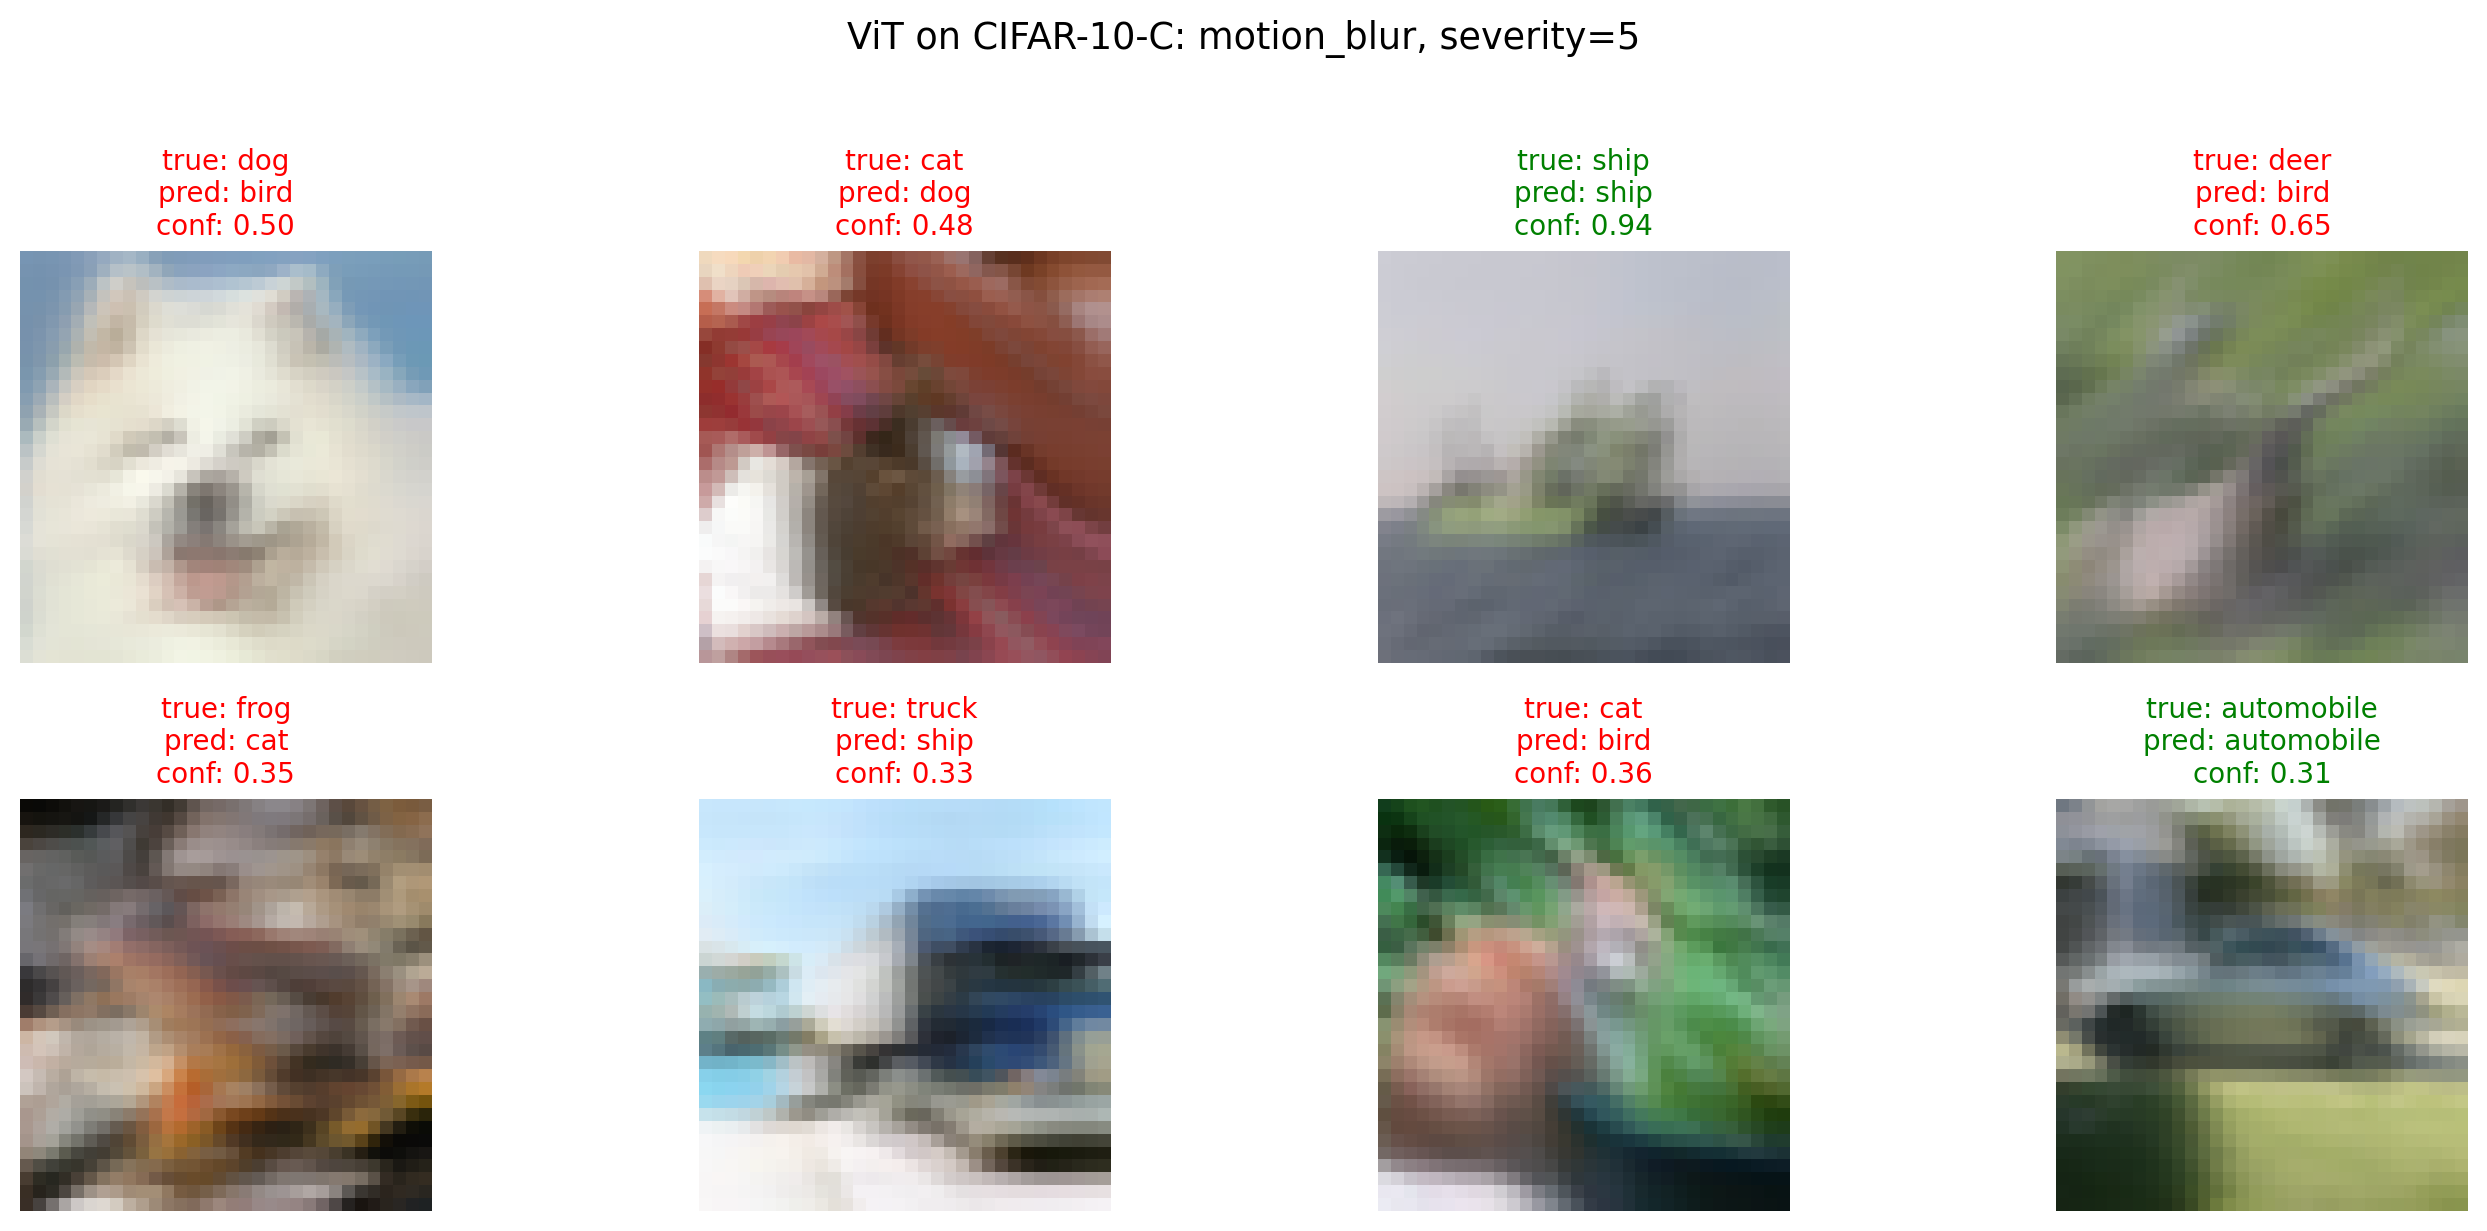

In [12]:
visualize_vit_predictions_on_c10c(
    vit_stable_model,
    c10c_dir,
    corruption="motion_blur",
    severity=5,
    n=8
)

In [13]:
@torch.no_grad()
def corruption_breakdown_vit(model, c10c_dir, severity=5, batch_size=256):
    model.eval()
    accs = {}

    for corr in C10C_CORRUPTIONS:
        x_raw, y = load_c10c_corruption(c10c_dir, corr, severity)
        ds = CIFAR10CDataset(x_raw, y, transform=test_tf)
        dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

        correct, total = 0, 0
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).argmax(dim=-1)
            correct += (pred == yb).sum().item()
            total += yb.numel()

        accs[corr] = correct / total

    return accs

In [14]:
def plot_corruption_breakdown(accs, title="ViT robustness by corruption type"):
    items = sorted(accs.items(), key=lambda kv: kv[1])
    names = [k for k, _ in items]
    vals = [v for _, v in items]

    plt.figure(figsize=(10, 5),dpi=500)
    plt.bar(range(len(vals)), vals)
    plt.xticks(range(len(vals)), names, rotation=45, ha="right")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [15]:
accs_vit = corruption_breakdown_vit(vit_stable_model, c10c_dir, severity=5)

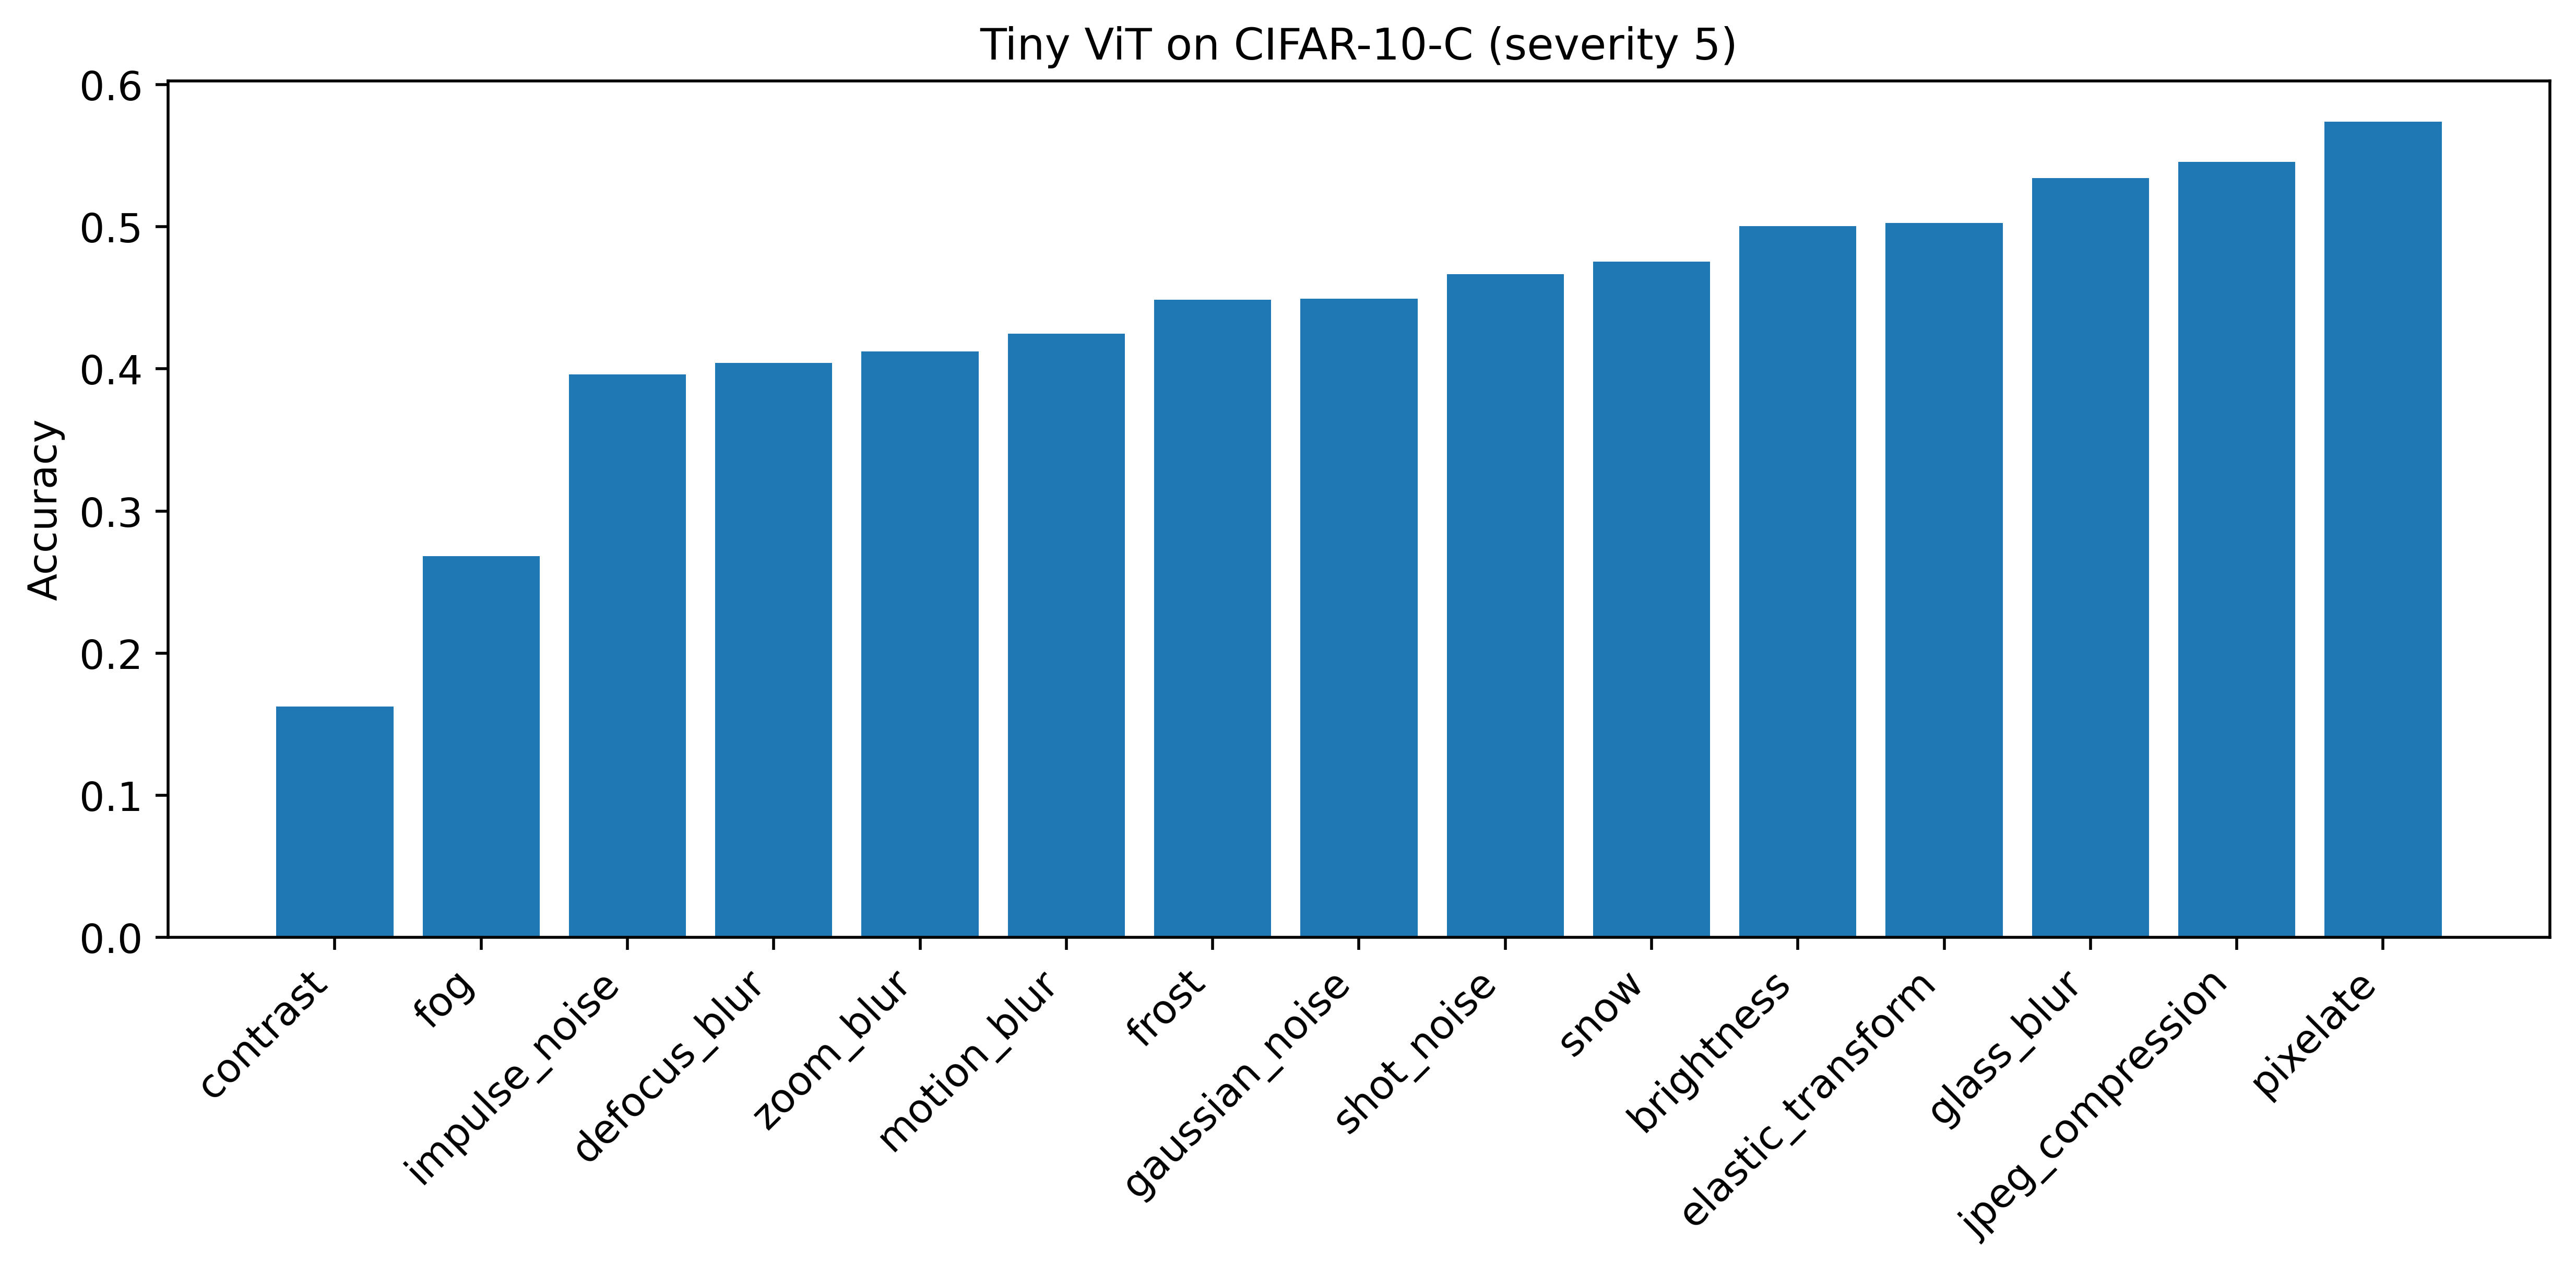

In [16]:
plot_corruption_breakdown(accs_vit, title="Tiny ViT on CIFAR-10-C (severity 5)")

In [17]:
def plot_two_corruption_breakdowns(accs_a, accs_b, label_a="stable", label_b="unstable"):
    names = sorted(accs_a.keys())
    vals_a = [accs_a[k] for k in names]
    vals_b = [accs_b[k] for k in names]

    x = np.arange(len(names))
    w = 0.38

    plt.figure(figsize=(11, 5),dpi=500)
    plt.bar(x - w/2, vals_a, width=w, label=label_a)
    plt.bar(x + w/2, vals_b, width=w, label=label_b)

    plt.xticks(x, names, rotation=45, ha="right")
    plt.ylabel("Accuracy")
    plt.title("ViT robustness by corruption type")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [18]:
accs_vit_stable = corruption_breakdown_vit(vit_stable_model, c10c_dir, severity=5)
accs_vit_unstable = corruption_breakdown_vit(vit_unstable_model, c10c_dir, severity=5)

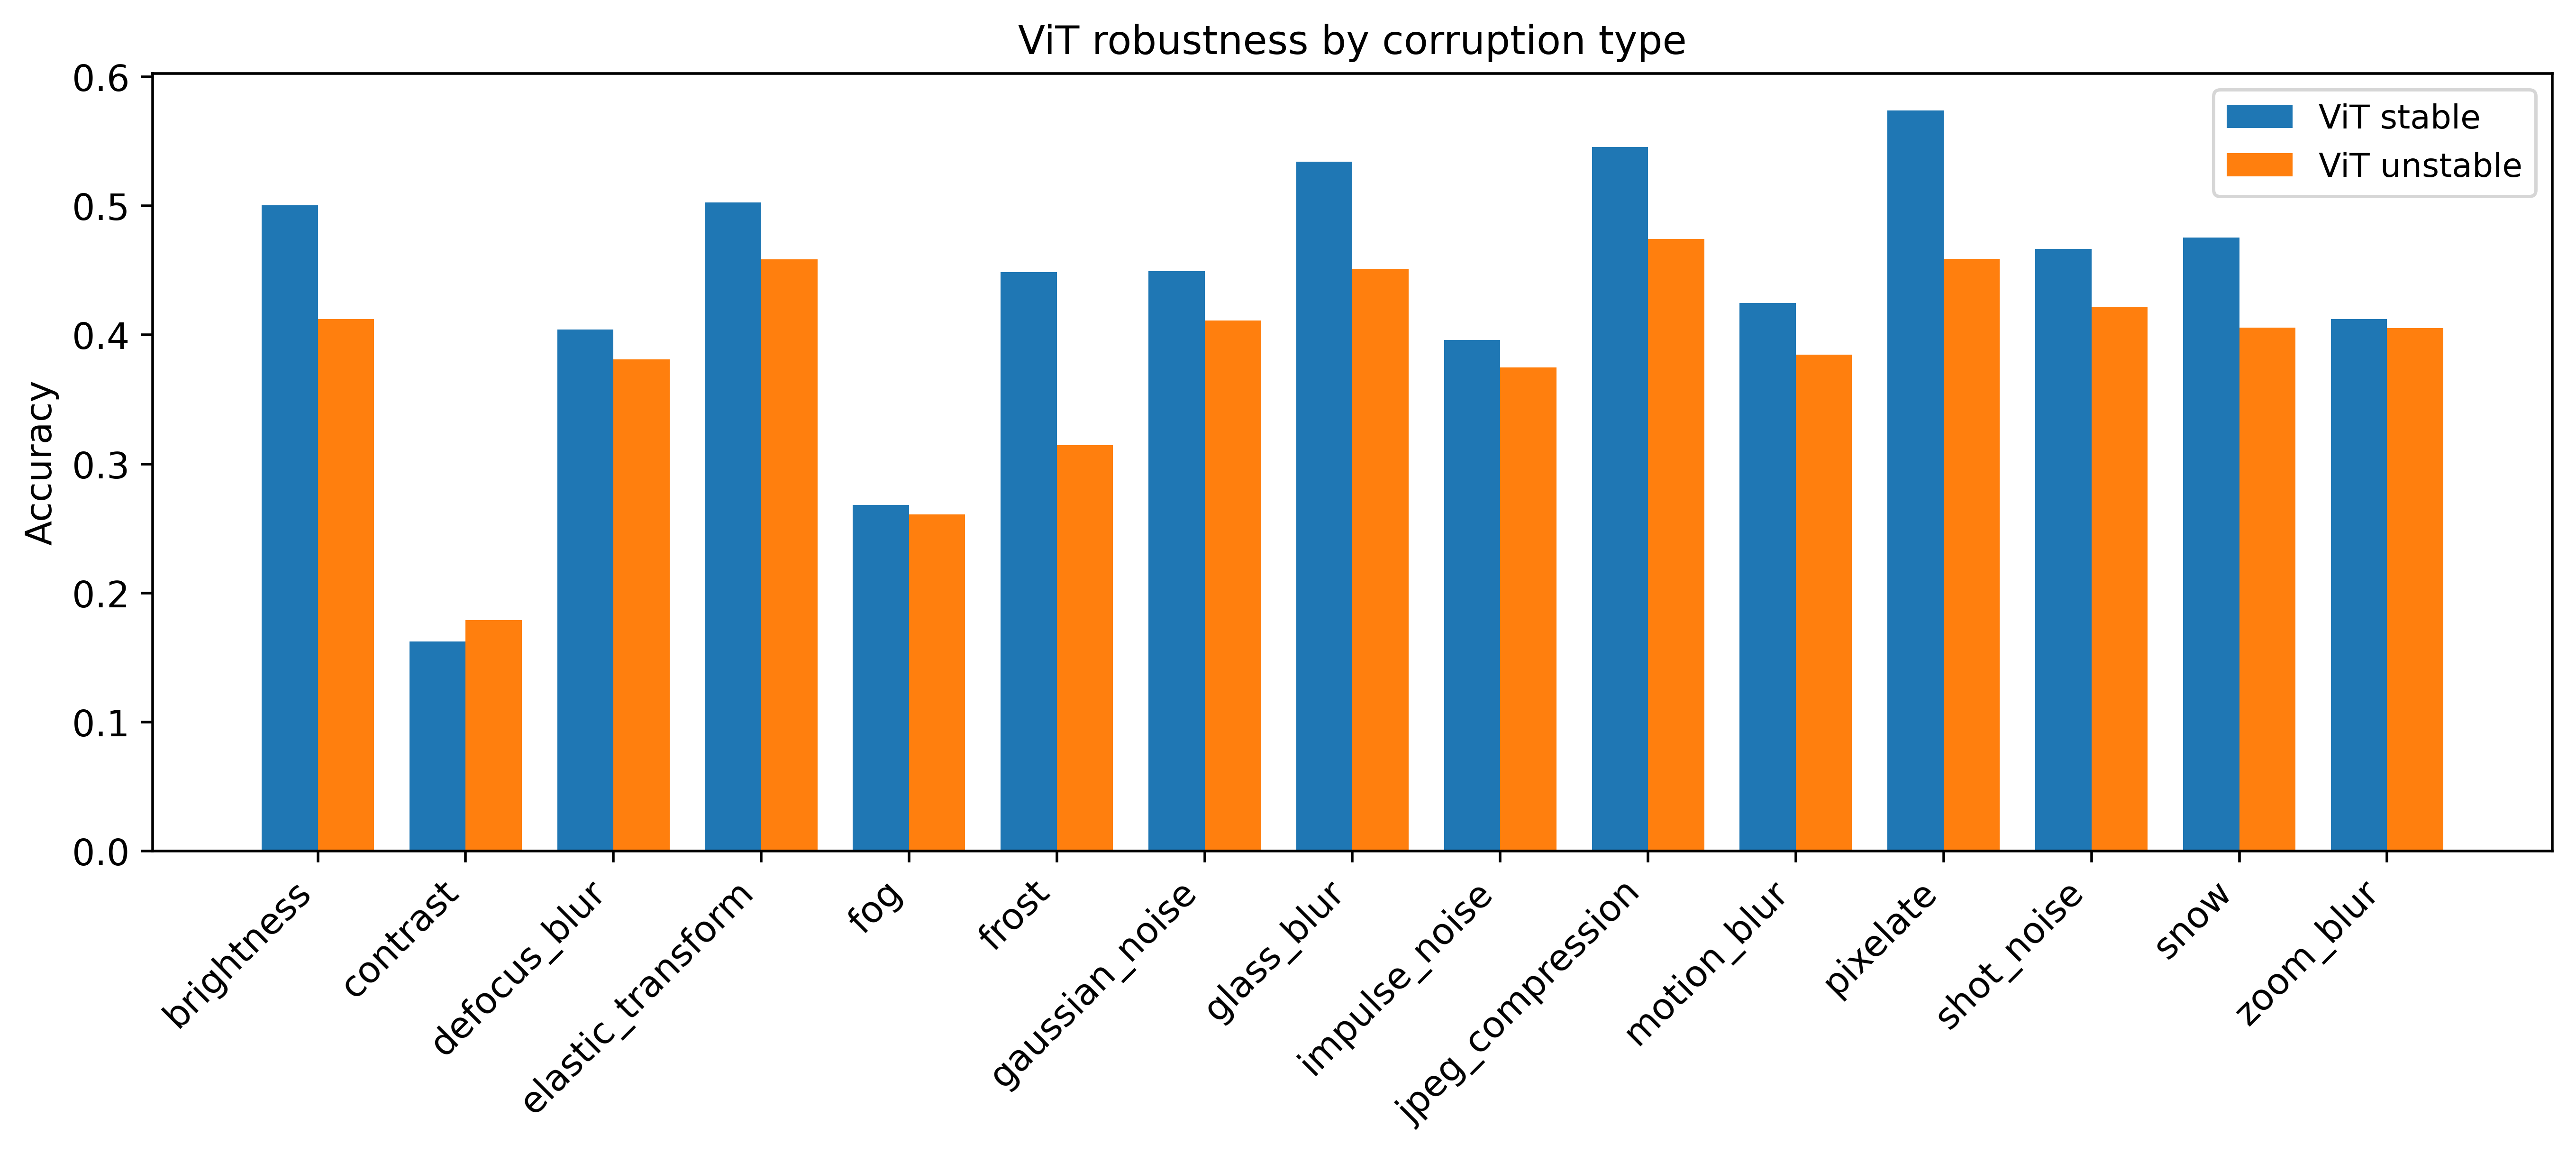

In [19]:
plot_two_corruption_breakdowns(
    accs_vit_stable,
    accs_vit_unstable,
    label_a="ViT stable",
    label_b="ViT unstable"
)

In [20]:
attention_maps = {}

def get_attention_hook(name):
    def hook(module, input, output):
        # output structure may vary depending on version
        attention_maps[name] = output
    return hook

import timm

vit_timm = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=10
).to(device)


@torch.no_grad()
def vit_patch_occlusion_map(model, img_tensor, target_class=None, patch=4):
    """
    img_tensor: [3,32,32] normalized
    returns heatmap [H/patch, W/patch]
    """
    model.eval()
    x = img_tensor.unsqueeze(0).to(device)

    logits = model(x)
    if target_class is None:
        target_class = logits.argmax(dim=-1).item()

    base_score = logits[0, target_class].item()

    H, W = img_tensor.shape[1], img_tensor.shape[2]
    gh, gw = H // patch, W // patch
    heat = np.zeros((gh, gw), dtype=np.float32)

    for i in range(gh):
        for j in range(gw):
            x_occ = x.clone()
            h0, h1 = i * patch, (i + 1) * patch
            w0, w1 = j * patch, (j + 1) * patch

            # zero-out patch in normalized space
            x_occ[:, :, h0:h1, w0:w1] = 0.0

            score = model(x_occ)[0, target_class].item()
            heat[i, j] = base_score - score

    return heat

In [21]:
def show_patch_occlusion_map(model, c10c_dir, corruption="gaussian_noise", severity=5, idx=0, patch=4):
    x_raw, y = load_c10c_corruption(c10c_dir, corruption, severity)

    img_pil = torchvision.transforms.functional.to_pil_image(x_raw[idx])
    img_tensor = test_tf(img_pil)  # normalized

    heat = vit_patch_occlusion_map(model, img_tensor, patch=patch)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4),dpi=500)

    axes[0].imshow(unnormalize(img_tensor),interpolation='bicubic')
    axes[0].set_title(f"Input: {corruption}, sev={severity}")
    axes[0].axis("off")

    axes[1].imshow(unnormalize(img_tensor),interpolation='bicubic')
    axes[1].imshow(
        heat,
        cmap="inferno",
        alpha=0.55,
        extent=(0, 32, 32, 0),
        interpolation="nearest"
    )
    axes[1].set_title("Patch occlusion sensitivity")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

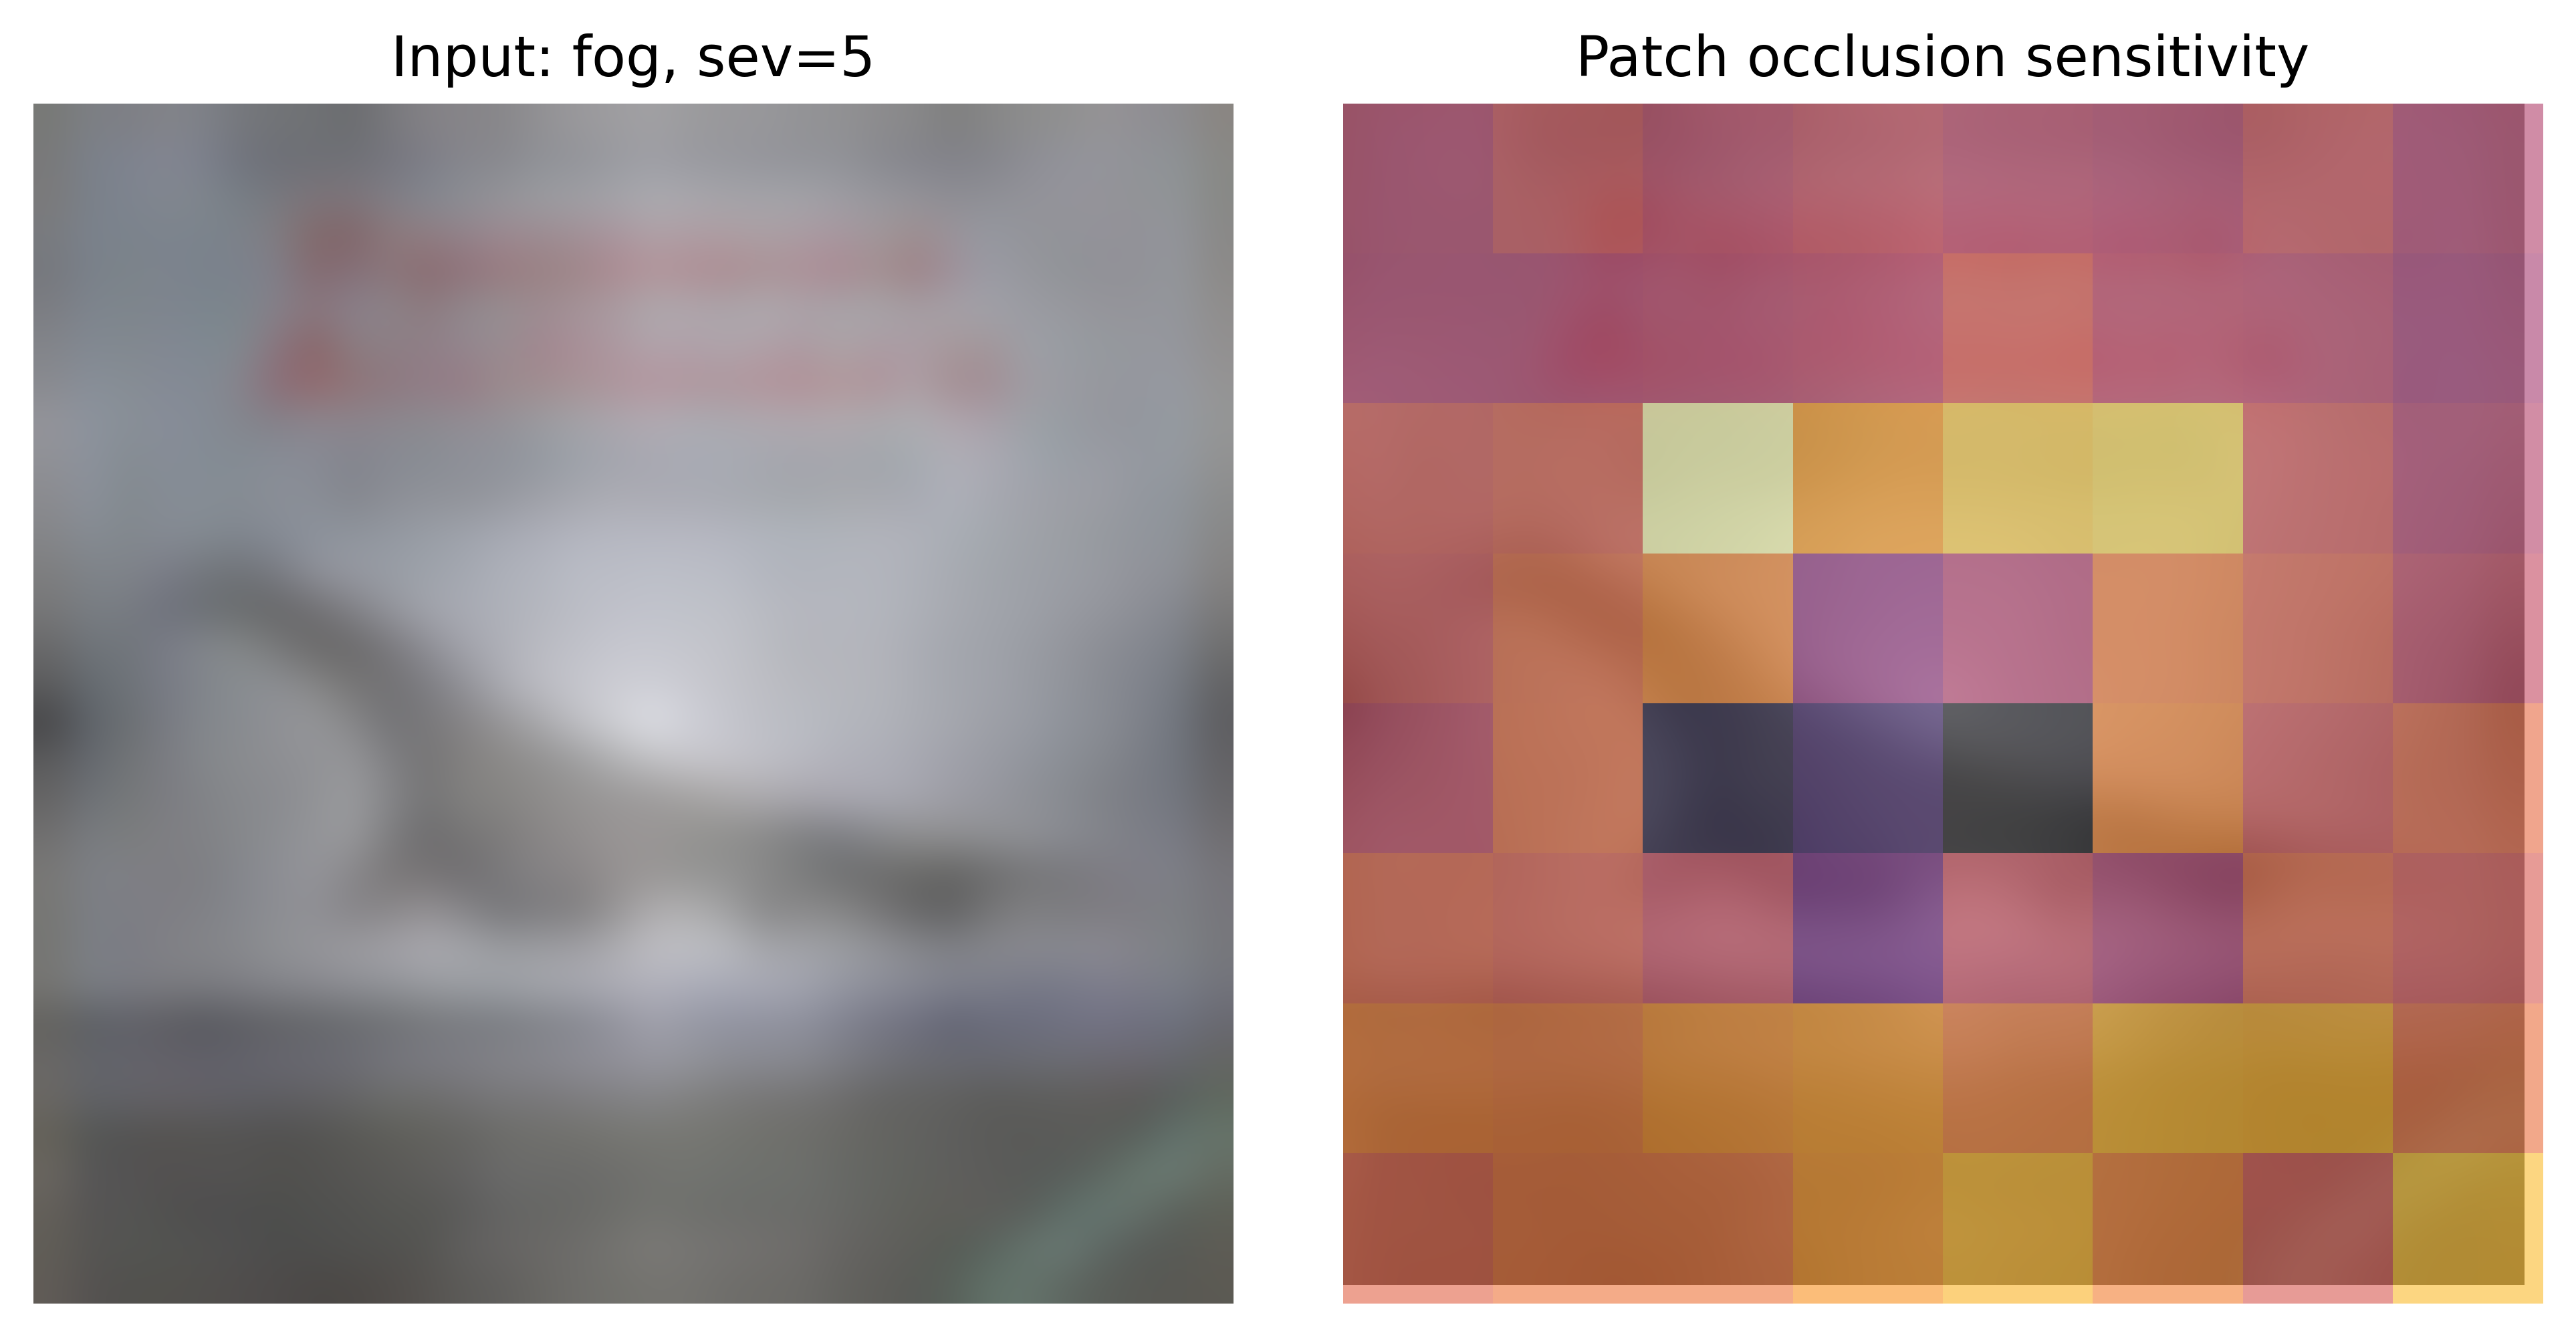

In [22]:
show_patch_occlusion_map(
    vit_stable_model,
    c10c_dir,
    corruption="fog",
    severity=5,
    idx=3,
    patch=4
)

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multi_corruption_overlay(logs_dict, outfile="appendix_multi_corr.pdf"):
    """
    logs_dict = {
        "fog": logs_fog,
        "gaussian_noise": logs_noise,
        "blur": logs_blur,
    }
    """

    plt.figure(figsize=(6.8, 5.2))

    for name, logs in logs_dict.items():
        S = np.array(logs["sigma_mean"])
        R = np.array(logs["c10c_acc_mean"])

        plt.scatter(S, R, s=45, alpha=0.75, label=name)

        # optional quadratic fit
        coeffs = np.polyfit(S, R, 2)
        S_fit = np.linspace(S.min(), S.max(), 200)
        R_fit = np.polyval(coeffs, S_fit)

        plt.plot(S_fit, R_fit, linewidth=1.5)

    plt.xlabel("Sensitivity")
    plt.ylabel(r"Robustness $\mathcal{R}_5$")
    plt.title("Sensitivity–robustness structure across corruption types")

    plt.legend(frameon=False)

    for spine in ["top", "right"]:
        plt.gca().spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(outfile, format="pdf", bbox_inches="tight")
    plt.show()

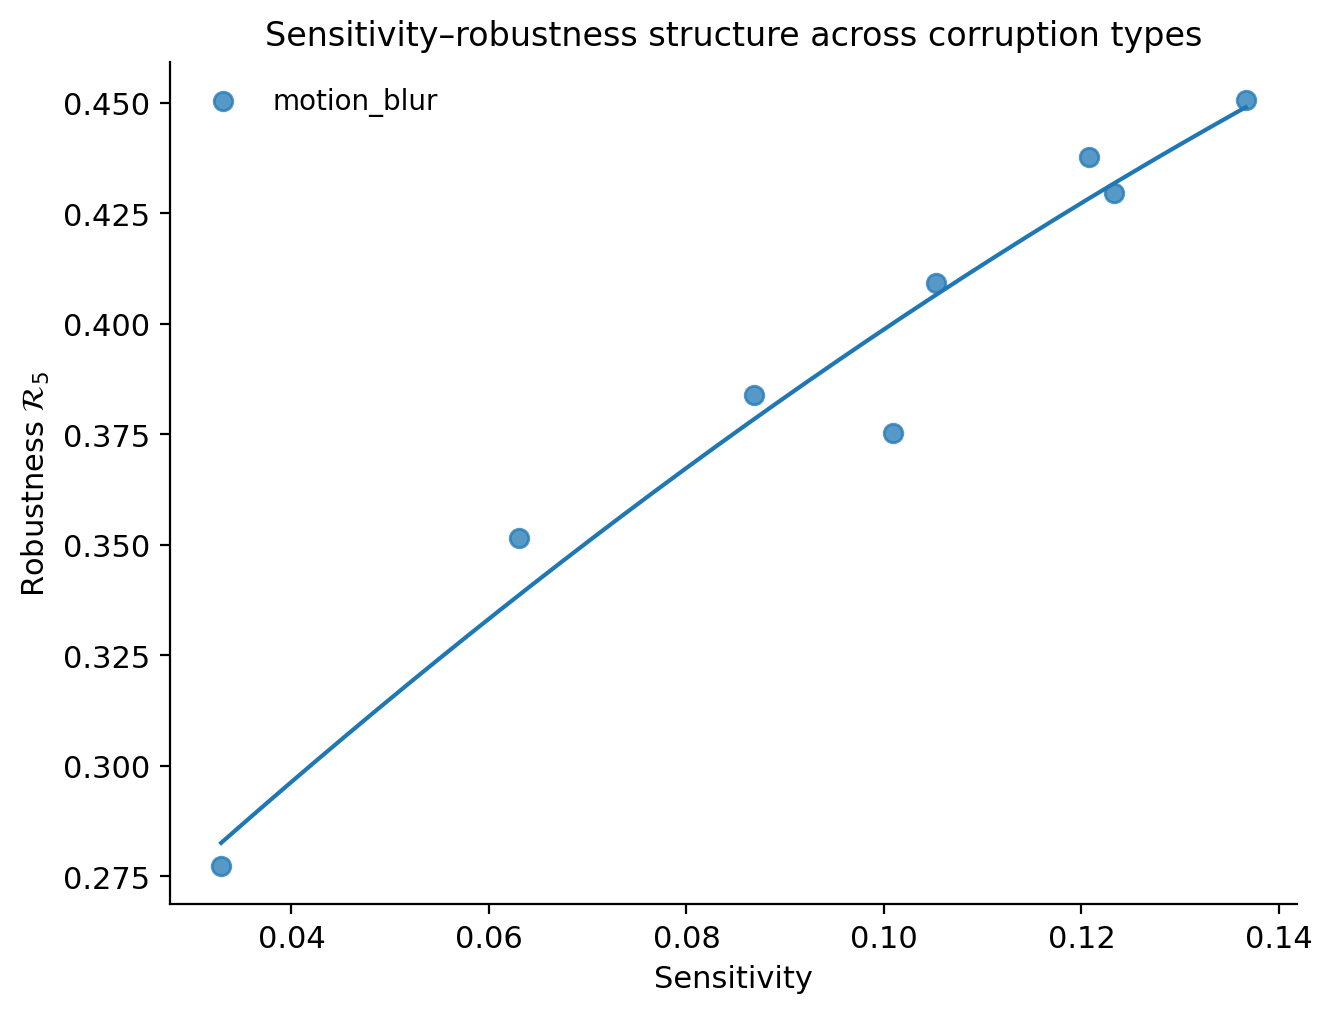

In [24]:
logs_dict = {
    "motion_blur": vit_stable_logs
}

plot_multi_corruption_overlay(logs_dict)